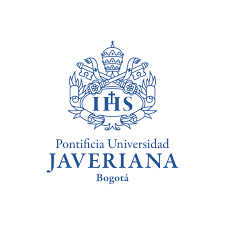
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Jesús David Romero Melo

Fecha de Inicio: 27 / 05 / 2026

Fecha actual: 27 / 05 / 2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**

### Levantamiento de variables de entorno pip

In [1]:
import os
import sys
sys.path.append('/usr/lib/python3/dist-packages/')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *
import findspark
findspark.init()
import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *
import random
import tensorflow as tf

I0000 00:00:1779982858.050523 1387341 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Levantamiento de sesión SPARK

In [2]:
configura = SparkConf()

configura.setAppName("Calidad_Agua_Romero")

sparkS = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)

sparkContextoS = sparkS.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos13")

SEMILLA = 42
os.environ['PYTHONHASHSEED'] = str(SEMILLA)
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/28 10:41:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/28 10:41:00 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/28 10:41:00 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/05/28 10:41:00 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/05/28 10:41:00 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/05/28 10:41:00 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.


Sesion creada: ProcesamientoDatos13


## **2.- Carga de Datos desde el HADOOP HDFS**

In [3]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkS.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

df00.show(5)

Found 11 items
-rw-r--r--   2 sistemas supergroup     977501 2026-03-10 15:27 /csv/CustomerChurn.csv
-rw-r--r--   2 sistemas supergroup      40868 2025-07-07 15:41 /csv/Fortune500USCompanies.csv
drwxr-xr-x   - sistemas supergroup          0 2025-10-16 14:17 /csv/auxiliar
-rw-r--r--   2 sistemas supergroup    4610348 2026-04-28 08:17 /csv/bank-full.csv
-rw-r--r--   2 sistemas supergroup      34635 2025-09-02 13:22 /csv/jugadores.csv
-rw-r--r--   2 sistemas supergroup    1082023 2025-09-02 13:22 /csv/resultados_futbol.csv
-rw-r--r--   2 sistemas supergroup     316971 2025-06-10 09:11 /csv/stroke_pyspark.csv
drwxr-xr-x   - sistemas supergroup          0 2025-06-18 15:36 /csv/taxi
drwxr-xr-x   - sistemas supergroup          0 2026-04-23 15:56 /csv/titanic
-rw-r--r--   2 sistemas supergroup      48036 2025-06-12 14:31 /csv/waterquality.csv
-rw-r--r--   2 sistemas supergroup      84199 2026-04-23 17:11 /csv/winequality-red.csv


+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [4]:
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

Se presenta las estadísticas de los datos a continuación:

In [5]:
for valor in df00.columns:
    df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+---------

+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------+

+-------+------------------+
|summary|      CONDUCTIVITY|
+-------+------------------+
|  count|               534|
|   mean| 684.9761904761905|
| stddev|1769.3297602834873|
|    min|               100|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|              BOD|
+-------+-----------------+
|  count|              534|
|   mean|5.339772727272726|
| stddev|8.500503922190218|
|    min|              0.2|
|    max|               NA|

### **Visualización de los DATOS NULOS**

Cantidad de Valores Nulos o Imposibles

In [6]:
df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones
* Se crea una vista para ser usada en las visualizaciones

In [7]:
df00.createOrReplaceTempView("df00_sql")

df01 = sparkS.sql('''Select * from df00_sql where TEMP is not null and 
    DO is not null and
    pH is not null and
    CONDUCTIVITY is not null and
    BOD is not null and
    NITRATE_N_NITRITE_N is not null and
    FECAL_COLIFORM is not null''')

### Se verifica la Cantidad de Valores Nulos o Imposibles

In [8]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### Tratamiento de datos

Se procede a cambiar los tipos de datos

In [9]:
df00.dtypes

df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))

df00.dtypes

##Se elimina la columna TOTAL_COLIFORM
df01 = df00.drop('TOTAL_COLIFORM')

df01.columns


['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

### Creación de Tablas para Visualizar los Datos

Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

Se crea una consulta por cada parámetro
Se hace una consulta para crear el vector de la tabla por cada parámetro
- pH
- CONDUCTIVITY
- BOD
- NITRATE_N_NITRITE_N
- FECAL_COLIFORM 

In [10]:
df01.createOrReplaceTempView("df01_sql")
do_parametro = sparkS.sql("Select DO from df01_sql")
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()
ph_parametro = sparkS.sql("Select ph from df01_sql")
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.ph).collect()
COND_parametro = sparkS.sql("Select CONDUCTIVITY from df01_sql")
COND_parametro = COND_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()
BOD_parametro = sparkS.sql("Select BOD from df01_sql")
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()
NN_parametro = sparkS.sql("Select NITRATE_N_NITRITE_N from df01_sql")
NN_parametro = NN_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()
FC_parametro = sparkS.sql("Select FECAL_COLIFORM from df01_sql")
FC_parametro = FC_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()

### Grafica Los parámetros para conocer sus características: DO y PH

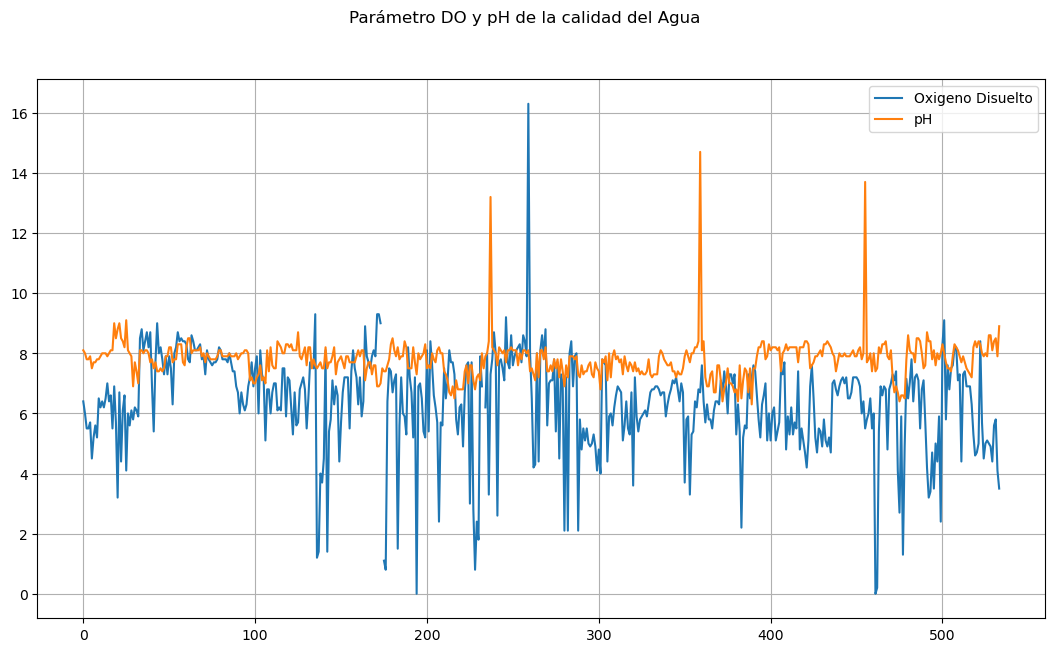

In [11]:
tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='pH')

fig.suptitle('Parámetro DO y pH de la calidad del Agua')

legend=ax1.legend()

plt.grid()
plt.show()


### Grafica Los parámetros para conocer sus características: BOD y Nitrogrenos

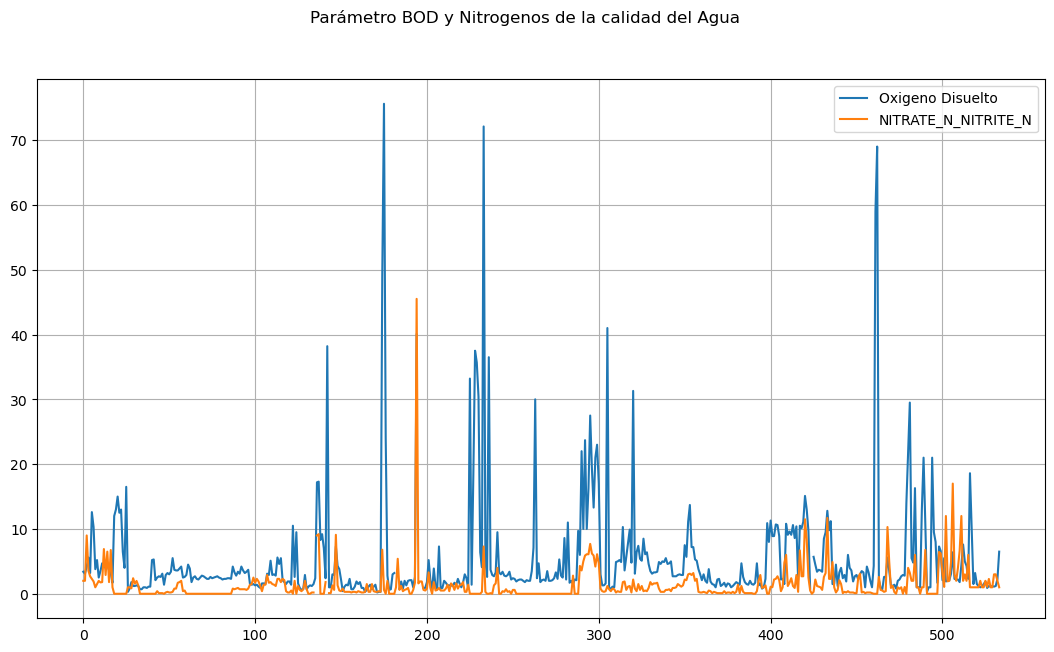

In [12]:
tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), BOD_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')

fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')

legend=ax1.legend()

plt.grid()
plt.show()


### Grafica Los parámetros para conocer sus características: FC y Conductividad

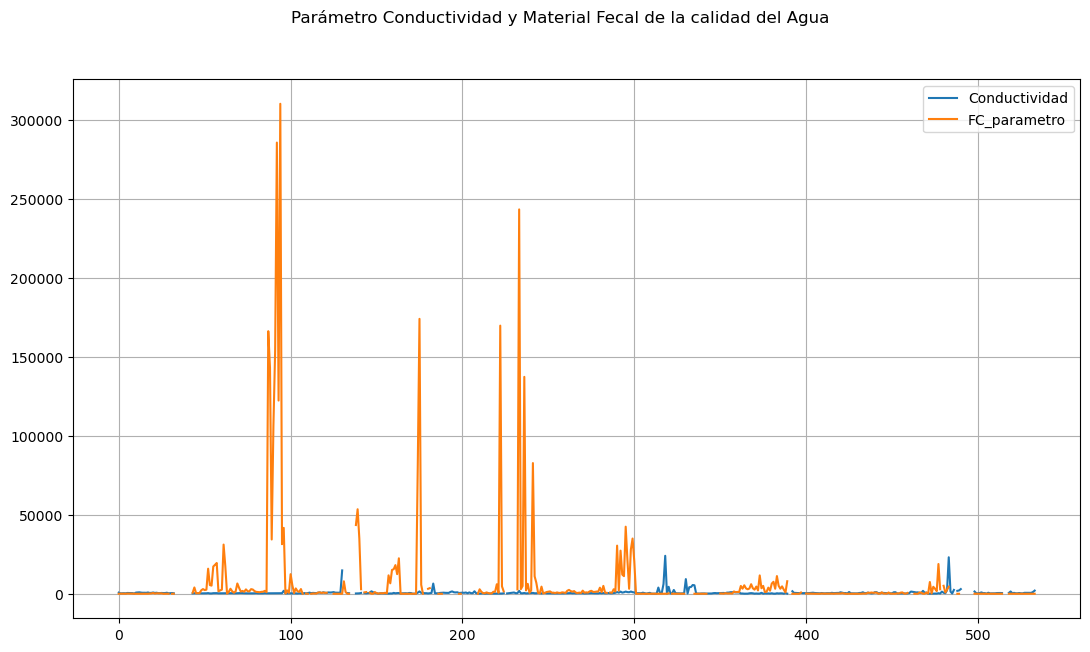

In [13]:
tam = len(do_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
ax1.plot(range(0,tam), FC_parametro, label='FC_parametro')

fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')

legend=ax1.legend()

plt.grid()
plt.show()


* Función definida por el usuario para definir el rango de calidad de agua según el pH
* Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

In [14]:
df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).
    when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).
    when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).
    when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

* Función definida por el usuario para definir el rango de la calidad del agua según DO

In [15]:
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
    when((df01.DO>=5.1) & (df01.DO<6.0), 80).
    when((df01.DO>=4.1) & (df01.DO<5.0), 60).
    when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

* Función definida por el usuario para definir el rango de la calidad del agua según COND

In [16]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
    when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
    when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
    when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))
    

* Función definida por el usuario para definir el rango de la calidad del agua según BOD

In [17]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
      when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
      when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
      when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

* Función definida por el usuario para definir el rango de la calidad del agua según NITRATE_N_NITRITE_N
    * 100: Agua Dulce
    * 80: Agua Moderada
    * 60: Agua Dura
    * 40: Agua muy Dura

In [18]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
      when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
      when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
      when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

* Función definida por el usuario para definir el rando de la calidad del agua según el Material Fecal
  *  100: Agua Dulce
  *  80: Agua Moderada
  *  60: Agua Dura
  *  40: Agua muy Dura

In [19]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
      when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
      when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
      when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

## El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua**

### El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua
A continuación se hace una inspección en general del df02

In [20]:
df02.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

In [21]:
df02.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

* Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica

* Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

In [22]:
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

df03.show(10)

df03.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **Calculo del Índice de Calidad del Agua**

* Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

In [23]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

* Intervalos de Índices para WQI

    * Excelente: agua dulce WQI = [0.0 , 25.0]
    * Buena: agua moderada WQI = (25.0 , 50.0]
    * Baja: agua dura WQI = (50.0 , 75.0]
    * Muy_Baja: agua muy dura WQI = (75.0 , 100.0]
    * Inadecuada: agua residual WQI > 100


Intervalos de Índices para WQI

    Excelente: agua dulce WQI = [0.0 , 25.0]
    Buena: agua moderada WQI = (25.0 , 50.0]
    Baja: agua dura WQI = (50.0 , 75.0]
    Muy_Baja: agua muy dura WQI = (75.0 , 100.0]
    Inadecuada: agua residual WQI > 100


In [24]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
   .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
   .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
   .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
   .otherwise('Inadecuada'))

df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

* Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua
* Impresión de nombre de regiones sobre el mapa

In [25]:
colEstado = 'STATE'
valNombres = df05.select(colEstado).distinct().collect()
valNombres = [v[colEstado] for v in valNombres]

print(valNombres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


### **Se cargan los datos de los mapas disponibles**

In [26]:
import geopandas as gpd

In [27]:
rutaMapas = "tallerWater/Indian_States.shp"

gpd01 = gpd.read_file(rutaMapas)

* Se visualiza el tipo de dataframe que da geopandas y las columnas 

In [28]:
print(type(gpd01))

gpd01.columns

<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

* Se visualizan los nombres de la columna de los estados "st_nm"

In [29]:
gpd01["st_nm"].unique()

array(['Andaman & Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara & Nagar Havelli',
       'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Andhra Pradesh'], dtype=object)

Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan con los nombres de los estados del dataframe de datos inicial

In [30]:
gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                     'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                    'Daman & Diu': 'Daman Diu', 
                     'Jammu & Kashmir': 'Jammu Kashmir',
                     'NCT of Delhi' : 'Delhi'
                      })

gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
* nombre de "st_nm" que sea "STATE"
* Se combinan es formato pandas para pintar el mapa
* Se garantizan los puntos dentro del mapa
* Se eliminan los duplicados

In [31]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [32]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### **Se pinta el mapa inicial**

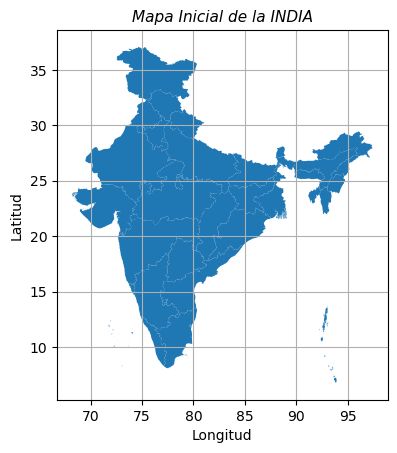

In [33]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

* Se requiere superponer las etiquetas de los estados de la India en el MAPA

In [34]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [35]:
from adjustText import adjust_text

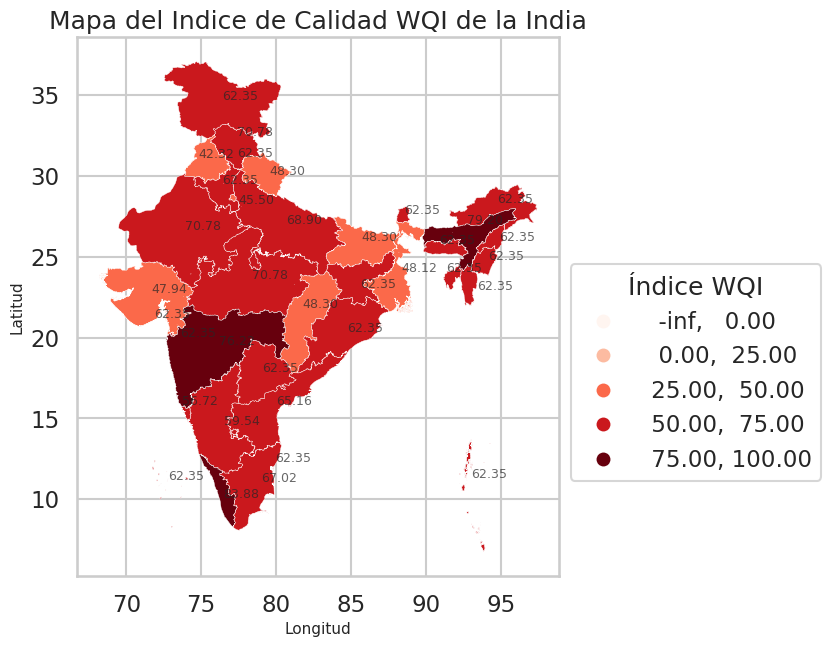

In [36]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

### **Histograma de WQI por Estado**

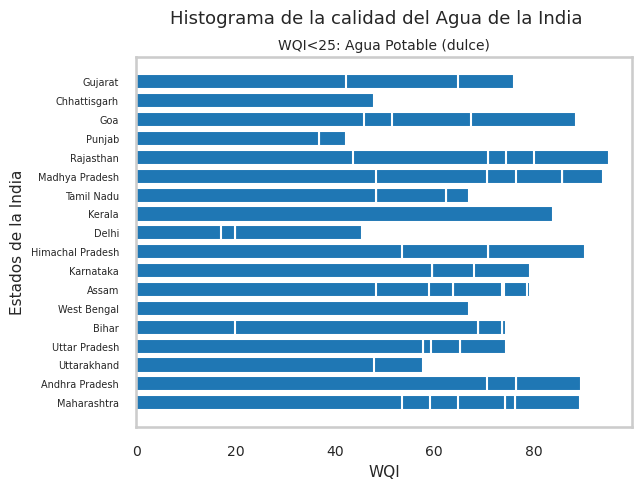

In [37]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkS.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkS.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

### **Creación de Modelo: Calidad de Agua en la India**

    * Se requiere predecir el parámetro WQI
    * Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    * Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    * Se importa Keras Sequential Layers Dense
    * Se inicializa el modelo, y se añaden las capas
    * Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    * Se realiza el experimento sobre los datos de entrenamiento
    * Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [38]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [39]:
# dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
# dfPredecir = df06.select('WQI')
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=['qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal'],
    outputCol='features'
)

df_spark_completo = assembler.transform(
    df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal','WQI')
)

train_spark, test_spark = df_spark_completo.randomSplit([0.8, 0.2], seed=42)

#dfcalidad.show(5)
#dfPredecir.show(5)

In [40]:

from sklearn.model_selection import train_test_split

train_pd = train_spark.toPandas()
test_pd  = test_spark.toPandas()

dataTrain = train_pd[['qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal']]
dataTest  = test_pd[['qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal']]
predTrain = train_pd[['WQI']]
predTest  = test_pd[['WQI']]
#dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [41]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (452, 6)
Cantidad de datos Prueba: (82, 6)
Cantidad de datos Predicción del Entrenamiento: (452, 1)
Cantidad de datos Predicción de Prueba: (82, 1)


## Implementación modelos de aprendizaje

### Red Neuronal

In [42]:
## Se importa la instancia TensorFlow
import keras
from keras.models import Sequential
from keras.layers import Dense

In [43]:
epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/opt/conda/envs/rapKernel_v4/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1779982881.109931 1387341 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Para optimizar el modelo se usa el optimizador ADAM
La compilación se ajusta a la pérdida del error cuadrático

In [44]:

keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [45]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
import time
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [47]:
inicio_nn = time.time()
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote, verbose=0)
fin_nn = time.time()
tiempo_nn = fin_nn - inicio_nn

In [48]:
predict_train = modelo01.predict(dataTrain)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


Se hace la predicción sobre train para comparar contra el de test

In [49]:
rmse_nn_train = np.sqrt(mean_squared_error(predTrain, predict_train))
print(f"Red Neuronal → RMSE: {rmse_nn_train:.4f} ")

Red Neuronal → RMSE: 0.0228 


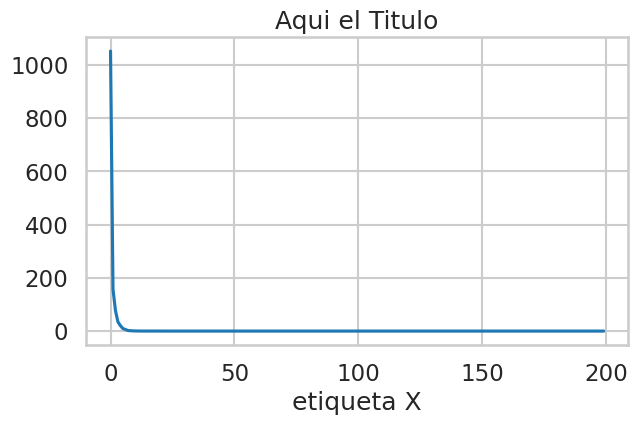

In [50]:
plt.figure(figsize=(7,4))
plt.plot(ejecutarK.history['loss'])
plt.title("Aqui el Titulo")
plt.xlabel("etiqueta X")
plt.show()

In [51]:
predModelo01_Test = modelo01.predict(dataTest)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [52]:
# Métricas
rmse_nn = np.sqrt(mean_squared_error(predTest, predModelo01_Test))
r2_nn   = r2_score(predTest, predModelo01_Test)

print(f"Red Neuronal → RMSE: {rmse_nn:.4f} | R²: {r2_nn:.4f} | Tiempo: {tiempo_nn:.2f}s")

Red Neuronal → RMSE: 0.2305 | R²: 0.9998 | Tiempo: 6.49s


#### Se pinta la predicción

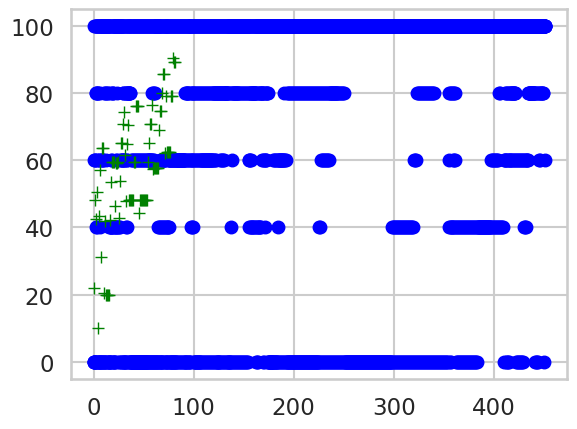

In [53]:

plt.plot(dataTrain, 'bo', predModelo01_Test, 'g+')
plt.show()

### Random Forest

In [54]:
from pyspark.ml.regression import RandomForestRegressor

from pyspark.ml.evaluation import RegressionEvaluator


train_spark, test_spark = df_spark_completo.randomSplit([0.8, 0.2], seed=42)

# Preparar features en formato Spark
#assembler = VectorAssembler(
#    inputCols=['qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal'],
#    outputCol='features'
#)
#df_spark = assembler.transform(df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal','WQI'))

#train_rf, test_rf = df_spark.randomSplit([0.8, 0.2], seed=1)

rf = RandomForestRegressor(featuresCol='features', labelCol='WQI', numTrees=100, seed=1)

inicio_rf = time.time()
modelo_rf = rf.fit(train_spark)
fin_rf = time.time()
tiempo_rf = fin_rf - inicio_rf

pred_rf_train = modelo_rf.transform(train_spark)

pred_rf = modelo_rf.transform(test_spark)

evaluador = RegressionEvaluator(labelCol='WQI', predictionCol='prediction')
rmse_rf_train = evaluador.setMetricName('rmse').evaluate(pred_rf_train)
rmse_rf = evaluador.setMetricName('rmse').evaluate(pred_rf)
r2_rf   = evaluador.setMetricName('r2').evaluate(pred_rf)

print(f"Random Forest  → RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f} | Tiempo: {tiempo_rf:.2f}s")

# Importancia de variables
print(modelo_rf.featureImportances)

[Stage 78:>                                                         (0 + 1) / 1]

Random Forest  → RMSE: 5.2929 | R²: 0.9053 | Tiempo: 1.25s
(6,[0,1,2,3,4,5],[0.03281048393747541,0.28487118934783406,0.1491160253625442,0.08533587618178586,0.004732263561905404,0.443134161608455])


### Gradient Boosting

In [55]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(featuresCol='features', labelCol='WQI', maxIter=100, seed=1)

inicio_gbt = time.time()
modelo_gbt = gbt.fit(train_spark)  # mismo split que RF
fin_gbt = time.time()
tiempo_gbt = fin_gbt - inicio_gbt

pred_gbt_train = modelo_gbt.transform(train_spark)

pred_gbt = modelo_gbt.transform(test_spark)

rmse_gbt_train = evaluador.setMetricName('rmse').evaluate(pred_gbt_train)
rmse_gbt = evaluador.setMetricName('rmse').evaluate(pred_gbt)
r2_gbt   = evaluador.setMetricName('r2').evaluate(pred_gbt)

print(f"GBT → RMSE: {rmse_gbt:.4f} | R²: {r2_gbt:.4f} | Tiempo: {tiempo_gbt:.2f}s")


GBT → RMSE: 3.5074 | R²: 0.9584 | Tiempo: 18.04s


In [58]:
print("\n================== COMPARACIÓN DE MODELOS ==================")
print(f"{'Modelo':<15} {'RMSE Train':<14} {'RMSE Test':>8} {'R²':>8} {'Tiempo (s)':>12}")
print("-" * 60)
print(f"{'Red Neuronal':<12} {rmse_nn_train:>13f} {rmse_nn:>10.4f} {r2_nn:>10.4f} {tiempo_nn:>12.2f}")
print(f"{'Random Forest':<12} {rmse_rf_train:>13f} {rmse_rf:>10.4f} {r2_rf:>10.4f} {tiempo_rf:>12.2f}")
print(f"{'GBT':<12} {rmse_gbt_train:>13f} {rmse_gbt:>10.4f} {r2_gbt:>10.4f} {tiempo_gbt:>12.2f}")
print("=" * 60)


================== COMPARACIÓN DE MODELOS ==================
Modelo          RMSE Train     RMSE Test       R²   Tiempo (s)
------------------------------------------------------------
Red Neuronal      0.022814     0.2305     0.9998         6.49
Random Forest      4.270931     5.2929     0.9053         1.25
GBT               0.107605     3.5074     0.9584        18.04


## Análisis de resultados

### 1. Precisión

esa altísima precisión de los tres modelos no es casualidad. El WQI se calcula a partir de los mismos seis sub-índices que usamos como variables de entrada. La relación entre entrada y salida es, en esencia, una función matemática ponderada. Por eso cualquier modelo flexible la aprende con facilidad. Es importante decirlo con honestidad: en un problema con variables genuinamente independientes, estos valores de R² no serían alcanzables con tan pocos datos

### 2. Precisión comparativa real

la ventaja de la red neuronal se explica por la naturaleza de esa función. Es continua y suave, y las neuronas con activación ReLU la aproximan mejor que los árboles, que construyen fronteras por escalones.

### 3. Limitación RN de acuerdo a la arquitectura

la red neuronal tiene una limitación crítica en el contexto de alto volumen de datos. Para entrenarse, necesita convertir los datos de Spark a Pandas, lo que colapsa todo en un solo nodo. Con 534 registros es imperceptible; pero con millones, sería un cuello de botella que podría tumbar el nodo principal.

### 4. Ventaja RM y GBT

Random Forest y GBT no tienen ese problema. Operan distribuidos de extremo a extremo; los datos nunca abandonan el ecosistema Spark.

### Conclusiones en cuanto al procesamiento distribuido

Si bien la red neuronal demostró un comportamiento significativamente mejor hay que mencionar que en terminos del procesamiento distribuido tiene una limitante y es que en el momento que pasa a Pandas sale de Spark, perdiendo por lo menos para el entrenamiento y la predicción la capacidad de aprovechamiento de los recursos del cluster. Con un dataset tan pequeño como el que se tiene no se percibe un problema que sea significativo, sin embargo para conjuntos de datos mucho más grandes que es lo usual en estas arquitecturas, puede ser un cuello de botella problemático. Cosa que no ocurre con los otros dos modelos evaluados, ya que estos corren directamente en Spark aprovechando la arquitectura. 

Al hacer una breve investigación sobre posibles alternativas de Redes Neuronales directamente en Spark se encontró que lo más cercano es un perceptron clasificador multicapa, el cual no es util en nuestro caso pues las salidas no son categorias. La razón de esto es que Spark fue diseñado para procesamiento distribuido de datos tabulares a gran escala, contexto en el que RF y GBT tienen implementaciones nativas maduras en MLlib, mientras que las redes neuronales profundas dependen de frameworks especializados como TensorFlow o PyTorch que aún no tienen integración nativa completa con el ecosistema Spark.